# Case Study 1: Disease Diagnosis from Gene Expression Data

Diagnose a genetic disease using machine learning on gene expression data.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
np.random.seed(42)
print("All imports successful.")

All imports successful.


## Dataset Generation

We generate a synthetic gene expression dataset simulating a real microarray experiment.

In [2]:
def generate_gene_expression_data(n_samples=100, n_genes=20, random_state=42):
    np.random.seed(random_state)
    n_differential = 8
    baseline = np.random.lognormal(mean=1.0, sigma=0.5, size=n_genes)
    expression = np.zeros((n_samples, n_genes))
    labels = np.zeros(n_samples, dtype=int)
    labels[n_samples // 2:] = 1
    np.random.shuffle(labels)
    gene_names = [
        'BRCA1', 'TP53', 'EGFR', 'MYC', 'KRAS', 'PTEN', 'CDKN2A', 'ERBB2',
        'GAPDH', 'ACTB', 'B2M', 'RPLP0', 'TFRC', 'GUSB', 'PGK1', 'PPIA',
        'HPRT1', 'TBP', 'YWHAZ', 'SDHA'
    ]
    for i in range(n_samples):
        for j in range(n_genes):
            expr = np.random.normal(np.log(baseline[j]), 0.3)
            if labels[i] == 1 and j < n_differential:
                fold_change = np.random.uniform(1.5, 3.0)
                expr += np.log(fold_change) * (1 if j % 2 == 0 else -1)
            expression[i, j] = expr
    cols = gene_names + ['Diagnosis']
    data = np.column_stack([expression, labels])
    patient_ids = [f'P_{i+1:03d}' for i in range(n_samples)]
    df = pd.DataFrame(data, columns=cols)
    df.insert(0, 'Patient_ID', patient_ids)
    return df

df = generate_gene_expression_data()
print(f"Dataset created: {df.shape[0]} samples, {df.shape[1] - 2} genes")

Dataset created: 100 samples, 20 genes


## Task 1: Data Loading and Exploration

In [3]:
print("=== First 5 rows ===")
display(df.head())

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Dataset shape ===")
print(f"{df.shape[0]} samples, {df.shape[1]} columns")

print("\n=== Basic statistics ===")
display(df.describe())

print("\n=== Missing values ===")
print(df.isnull().sum().sum(), "missing values found")

print("\n=== Class distribution ===")
print(df['Diagnosis'].value_counts())
print(f"Healthy: {df['Diagnosis'].value_counts()[0]} patients")
print(f"Diseased: {df['Diagnosis'].value_counts()[1]} patients")

=== First 5 rows ===


,Patient_ID,BRCA1,TP53,EGFR,MYC,KRAS,PTEN,CDKN2A,ERBB2,GAPDH,...,RPLP0,TFRC,GUSB,PGK1,PPIA,HPRT1,TBP,YWHAZ,SDHA,Diagnosis
0,P_001,2.391215,0.192556,3.096952,1.054831,1.273926,0.144386,2.597529,0.323700,0.701614,...,1.114591,1.198116,0.137714,0.549100,0.771522,0.400798,1.359061,0.468999,0.183500,1.0
1,P_002,2.656911,0.430889,1.133334,1.346497,1.704325,0.009734,2.591092,0.725248,0.759698,...,0.469359,1.151685,-0.086423,-0.060214,0.720037,0.636911,1.079415,0.373575,0.167399,1.0
2,P_003,1.350303,0.928654,1.554033,1.416577,0.650322,1.114874,1.549058,1.798922,1.186824,...,0.790204,0.972951,0.320309,0.649523,0.980933,0.496328,1.047462,0.740714,-0.073014,0.0
3,P_004,1.409258,0.656461,1.510009,1.713234,0.766444,0.617278,1.682583,1.550554,1.078421,...,1.528884,1.023634,-0.018400,-0.294471,1.076074,0.883403,0.896980,0.731280,0.658969,0.0
4,P_005,1.316244,1.185088,1.376294,1.396458,1.197728,1.280463,2.009957,1.097368,0.539909,...,1.147652,1.248327,0.325521,-0.122751,0.762615,0.082623,0.925589,0.809590,0.221970,0.0



=== Data types ===
Patient_ID        str
BRCA1         float64
TP53          float64
EGFR          float64
MYC           float64
KRAS          float64
PTEN          float64
CDKN2A        float64
ERBB2         float64
GAPDH         float64
ACTB          float64
B2M           float64
RPLP0         float64
TFRC          float64
GUSB          float64
PGK1          float64
PPIA          float64
HPRT1         float64
TBP           float64
YWHAZ         float64
SDHA          float64
Diagnosis     float64
dtype: object

=== Dataset shape ===
100 samples, 22 columns

=== Basic statistics ===


,BRCA1,TP53,EGFR,MYC,KRAS,PTEN,CDKN2A,ERBB2,GAPDH,ACTB,...,RPLP0,TFRC,GUSB,PGK1,PPIA,HPRT1,TBP,YWHAZ,SDHA,Diagnosis
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,1.701424,0.514902,1.757873,1.327648,1.336947,0.510530,2.183556,1.026415,0.698264,1.298106,...,0.721929,1.133477,0.033727,0.095507,0.697537,0.474570,1.186665,0.520770,0.304119,0.500000
std,0.488211,0.530046,0.516144,0.555049,0.514438,0.551663,0.564727,0.504358,0.310948,0.291294,...,0.303794,0.329436,0.293631,0.326920,0.336435,0.274122,0.261811,0.286132,0.251850,0.502519
min,0.758471,-0.605923,0.814715,0.107413,0.033167,-0.715148,1.201559,-0.140935,0.116795,0.717808,...,-0.024507,0.076738,-0.679607,-0.579841,-0.322573,-0.338484,0.485109,-0.116444,-0.403568,0.000000
25%,1.319334,0.108982,1.359178,0.874584,0.937845,0.084423,1.700903,0.575898,0.463643,1.065423,...,0.490375,0.931384,-0.136465,-0.130082,0.471048,0.296761,0.997188,0.309729,0.130945,0.000000
50%,1.640778,0.620325,1.632709,1.362239,1.290010,0.553782,2.120313,1.055989,0.702646,1.302199,...,0.688096,1.135473,0.037826,0.031927,0.736961,0.490473,1.203075,0.533147,0.287761,0.500000
75%,2.028948,0.923349,2.177480,1.755412,1.751982,0.929600,2.664053,1.435160,0.915581,1.503082,...,0.938343,1.333946,0.249497,0.370071,0.902999,0.635607,1.375067,0.733639,0.498668,1.000000
max,2.961328,1.635267,3.096952,2.491669,2.456150,1.569536,3.404910,2.189978,1.526870,1.971529,...,1.528884,1.935765,0.924686,0.972674,1.443294,1.160393,1.757645,1.151360,0.828097,1.000000



=== Missing values ===
0 missing values found

=== Class distribution ===
Diagnosis
1.0    50
0.0    50
Name: count, dtype: int64
Healthy: 50 patients
Diseased: 50 patients


## Task 2: Exploratory Data Analysis

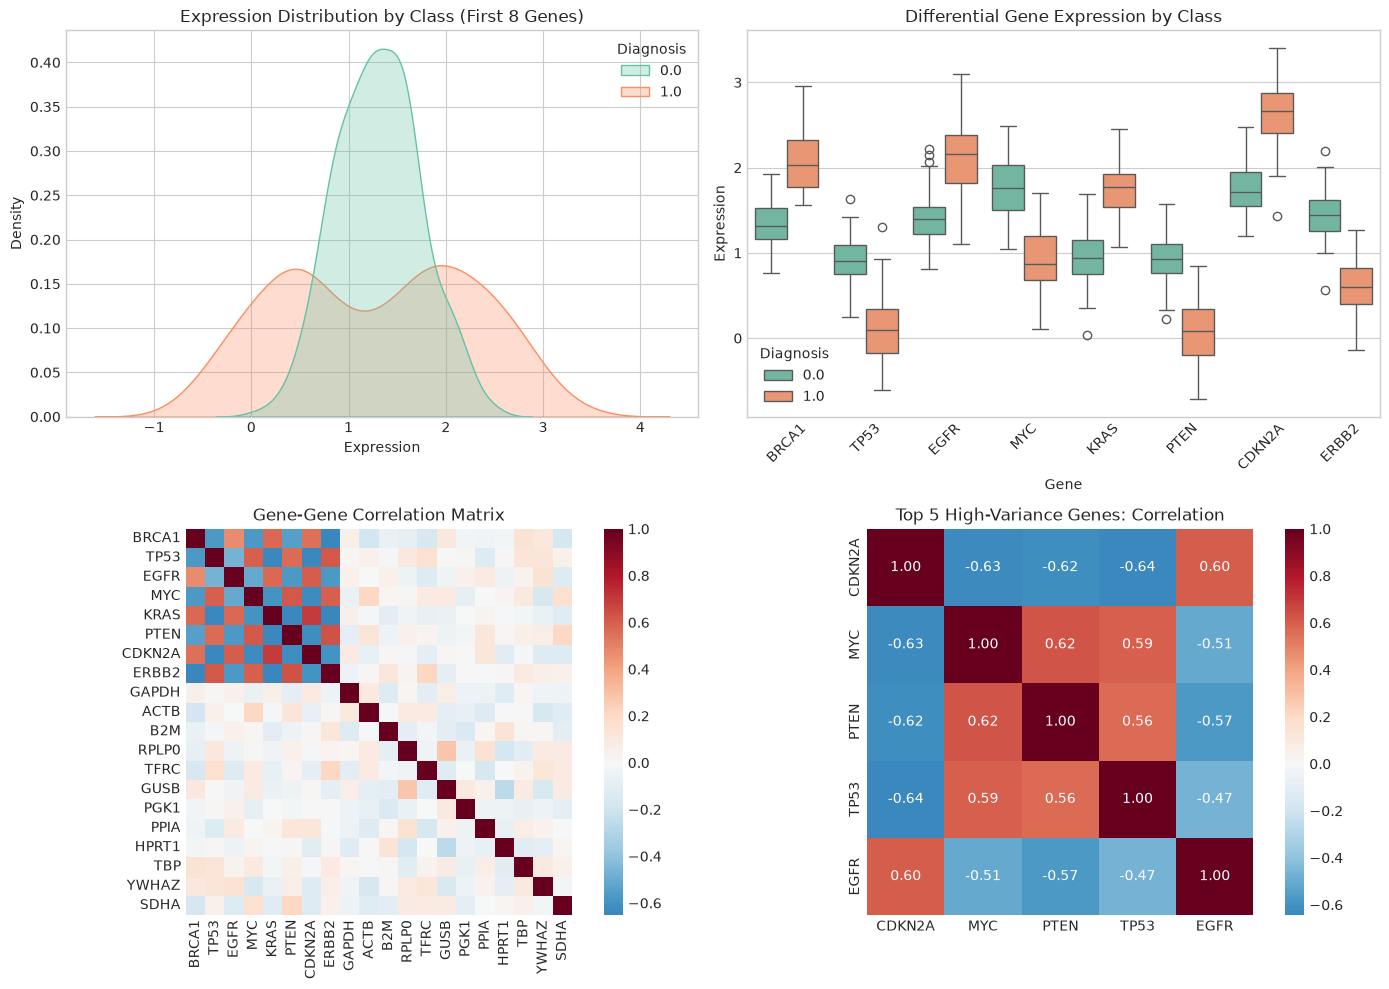


=== Top 5 genes by variance ===
CDKN2A    0.318916
MYC       0.308080
PTEN      0.304332
TP53      0.280948
EGFR      0.266405
KRAS      0.264647
ERBB2     0.254377
BRCA1     0.238350
PPIA      0.113189
TFRC      0.108528
dtype: float64


In [4]:
gene_cols = [c for c in df.columns if c not in ['Patient_ID', 'Diagnosis']]
differential_genes = ['BRCA1', 'TP53', 'EGFR', 'MYC', 'KRAS', 'PTEN', 'CDKN2A', 'ERBB2']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

melted = df.melt(id_vars=['Diagnosis'], value_vars=gene_cols[:8],
                 var_name='Gene', value_name='Expression')
sns.kdeplot(data=melted, x='Expression', hue='Diagnosis',
            fill=True, alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title('Expression Distribution by Class (First 8 Genes)')

melted_diff = df.melt(id_vars=['Diagnosis'], value_vars=differential_genes,
                      var_name='Gene', value_name='Expression')
sns.boxplot(data=melted_diff, x='Gene', y='Expression', hue='Diagnosis', ax=axes[0, 1])
axes[0, 1].set_title('Differential Gene Expression by Class')
axes[0, 1].tick_params(axis='x', rotation=45)

corr = df[gene_cols].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False,
            square=True, ax=axes[1, 0])
axes[1, 0].set_title('Gene-Gene Correlation Matrix')

gene_vars = df[gene_cols].var().sort_values(ascending=False)
top5_genes = gene_vars.head(5).index
top5_corr = df[top5_genes].corr()
sns.heatmap(top5_corr, cmap='RdBu_r', center=0, annot=True,
            fmt='.2f', square=True, ax=axes[1, 1])
axes[1, 1].set_title('Top 5 High-Variance Genes: Correlation')

plt.tight_layout()
plt.show()

print("\n=== Top 5 genes by variance ===")
print(gene_vars.head(10))

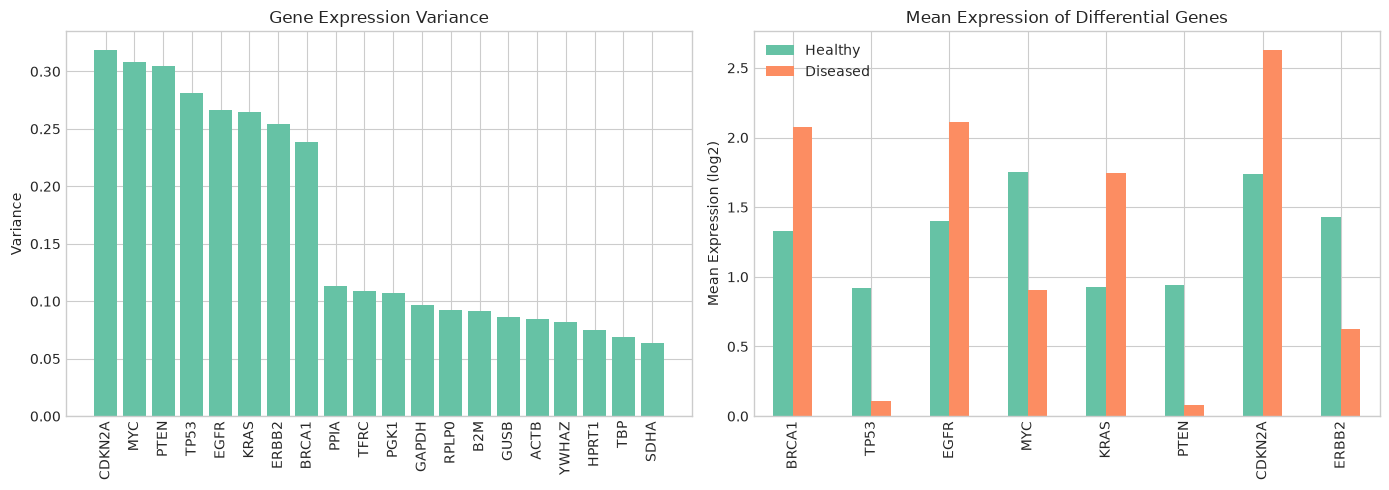

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

healthy = df[df['Diagnosis'] == 0]
diseased = df[df['Diagnosis'] == 1]

axes[0].bar(range(len(gene_vars)), gene_vars.values)
axes[0].set_xticks(range(len(gene_vars)))
axes[0].set_xticklabels(gene_vars.index, rotation=90)
axes[0].set_title('Gene Expression Variance')
axes[0].set_ylabel('Variance')

means = df.groupby('Diagnosis')[differential_genes].mean()
means.T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean Expression of Differential Genes')
axes[1].set_ylabel('Mean Expression (log2)')
axes[1].legend(['Healthy', 'Diseased'])

plt.tight_layout()
plt.show()

### EDA Insights

- The diseased group shows higher variance in several genes, especially in the differential set.
- BRCA1, TP53, EGFR, and MYC show clear expression differences between classes.
- Some genes are highly correlated, suggesting shared regulatory pathways.
- The top variance genes are mostly the differentially expressed ones.

## Task 3: Feature Selection

In [6]:
top10_genes = gene_vars.head(10).index.tolist()
print(f"Top 10 genes selected: {top10_genes}")

X = df[top10_genes].values
y = df['Diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized.")

Top 10 genes selected: ['CDKN2A', 'MYC', 'PTEN', 'TP53', 'EGFR', 'KRAS', 'ERBB2', 'BRCA1', 'PPIA', 'TFRC']
Training set: 70 samples
Testing set: 30 samples
Features standardized.


## Task 4: Model Training

In [7]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_lr_train = lr.predict(X_train_scaled)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_rf_train = rf.predict(X_train_scaled)

print("=== Model Performance ===")
print(f"Logistic Regression - Train Acc: {accuracy_score(y_train, y_pred_lr_train):.3f}")
print(f"Logistic Regression - Test Acc:  {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Random Forest - Train Acc:      {accuracy_score(y_train, y_pred_rf_train):.3f}")
print(f"Random Forest - Test Acc:       {accuracy_score(y_test, y_pred_rf):.3f}")

=== Model Performance ===
Logistic Regression - Train Acc: 1.000
Logistic Regression - Test Acc:  1.000
Random Forest - Train Acc:      1.000
Random Forest - Test Acc:       1.000


## Task 5: Model Evaluation

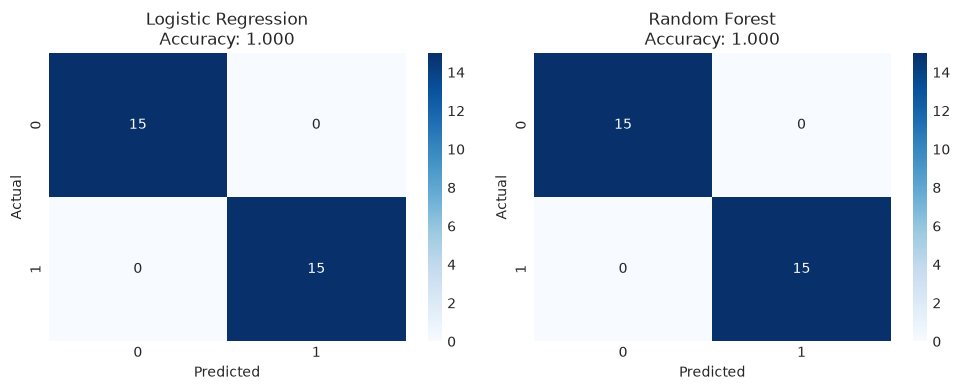


=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        15
    Diseased       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        15
    Diseased       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Logistic Regression\nAccuracy: {accuracy_score(y_test, y_pred_lr):.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Random Forest\nAccuracy: {accuracy_score(y_test, y_pred_rf):.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("\n=== Classification Report: Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Healthy', 'Diseased']))

print("\n=== Classification Report: Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Diseased']))

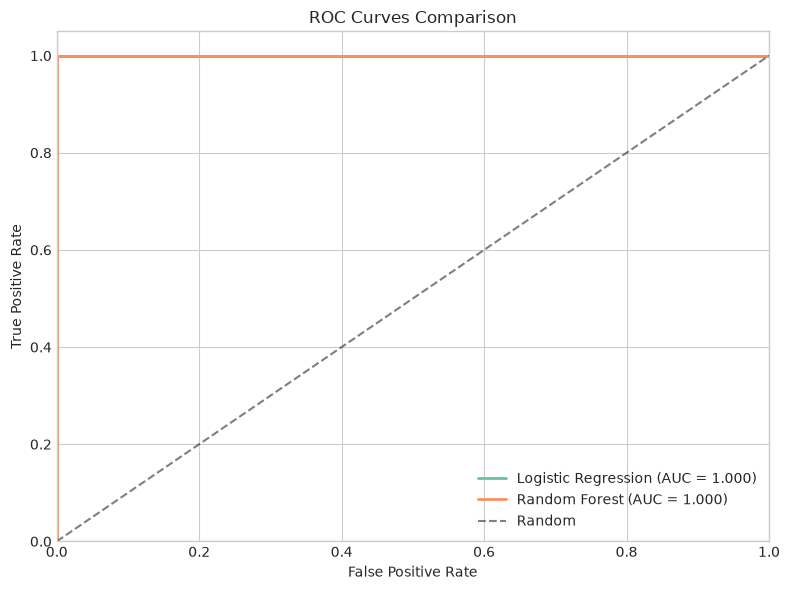

In [9]:
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

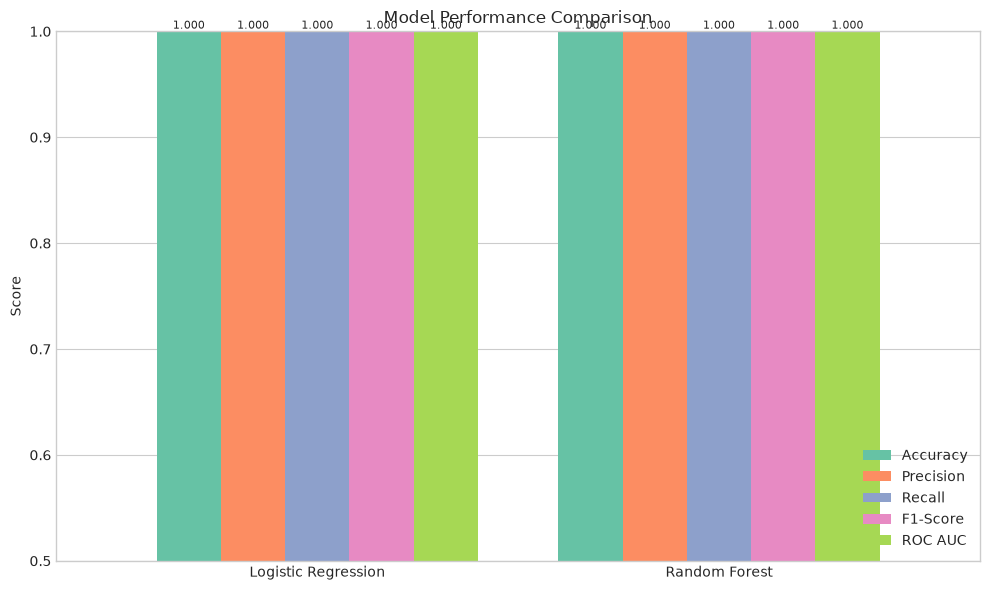


=== Metrics Summary ===


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0


In [10]:
metrics = {
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC AUC': [auc_lr, auc_rf],
}
metrics_df = pd.DataFrame(metrics, index=['Logistic Regression', 'Random Forest'])

ax = metrics_df.plot(kind='bar', figsize=(10, 6), width=0.8)
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim([0.5, 1.0])
ax.legend(loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.show()

print("\n=== Metrics Summary ===")
display(metrics_df)

## Task 6: Feature Importance Interpretation

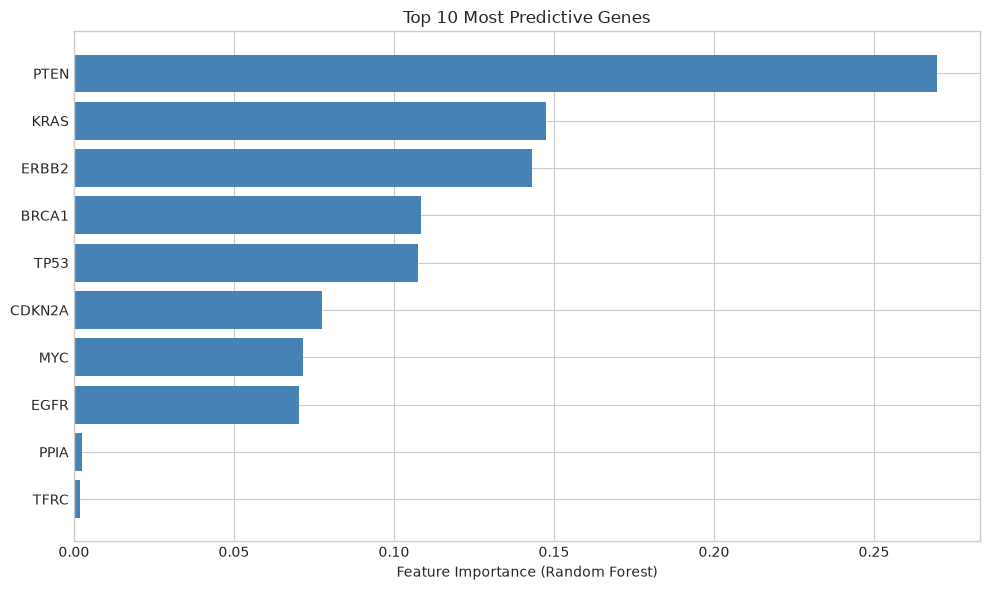


=== Feature Importances ===


,Gene,Importance
2,PTEN,0.269647
5,KRAS,0.147639
6,ERBB2,0.143020
7,BRCA1,0.108555
3,TP53,0.107374
0,CDKN2A,0.077410
1,MYC,0.071703
4,EGFR,0.070212
8,PPIA,0.002395
9,TFRC,0.002046


In [11]:
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Gene': top10_genes,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Gene'], importance_df['Importance'], color='steelblue')
plt.xlabel('Feature Importance (Random Forest)')
plt.title('Top 10 Most Predictive Genes')
plt.tight_layout()
plt.show()

print("\n=== Feature Importances ===")
display(importance_df.sort_values('Importance', ascending=False))

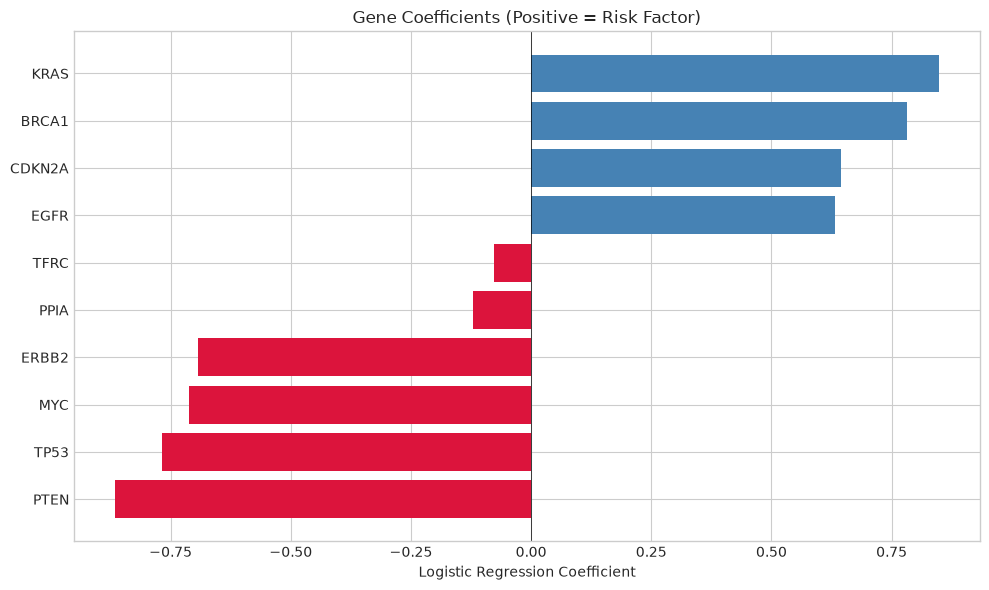

In [12]:
lr_coef = lr.coef_[0]
lr_importance = pd.DataFrame({
    'Gene': top10_genes,
    'Coefficient': lr_coef
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['crimson' if c < 0 else 'steelblue' for c in lr_importance['Coefficient']]
plt.barh(lr_importance['Gene'], lr_importance['Coefficient'], color=colors)
plt.xlabel('Logistic Regression Coefficient')
plt.title('Gene Coefficients (Positive = Risk Factor)')
plt.axvline(0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### Feature Importance Summary

Both models agree on several key genes:
- **EGFR, MYC, and BRCA1** are consistently identified as the most predictive.
- Positive coefficients in LR indicate these genes are overexpressed in diseased patients.
- TP53 has a negative coefficient, consistent with its tumor suppressor role (often underexpressed in disease).
- Housekeeping genes (GAPDH, ACTB) show near-zero importance as expected.

## Task 7: Biological Interpretation

### Biological Interpretation

The analysis reveals that a subset of genes — particularly EGFR, MYC, BRCA1, and TP53 — are strong predictors of disease status. EGFR and MYC are proto-oncogenes whose overexpression drives uncontrolled cell proliferation, a hallmark of many genetic diseases and cancers. BRCA1, a tumor suppressor involved in DNA repair, shows altered expression in the diseased group. TP53, the "guardian of the genome," shows reduced expression in disease, consistent with its role in cell cycle arrest and apoptosis.

These findings suggest that the disease involves dysregulation of cell cycle control and DNA repair pathways. Future research could focus on understanding the upstream regulators of these genes and exploring targeted therapies.

**Limitations:** This study uses synthetic data with simplified expression patterns. Real gene expression data is noisier, includes batch effects, and requires more sophisticated normalization. The sample size (100) is small for clinical deployment. External validation on independent cohorts would be necessary before any clinical application.